In [26]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

import seaborn as sns

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

print("Dataset path:", dataset_path)
print("\nTop-level contents:")

for item in dataset_path.iterdir():
    print(item)

Mounting files to /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented...
Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented

Top-level contents:
/kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images


In [5]:
image_root = dataset_path / "combined_images"

class_counts = {}

for class_folder in sorted(image_root.iterdir()):
    if class_folder.is_dir():
        image_files = [
            file for file in class_folder.iterdir()
            if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]

        class_counts[class_folder.name] = len(image_files)

class_counts_df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Image Count"]
)

display(class_counts_df)
print("Total images:", class_counts_df["Image Count"].sum()
     )

,Class,Image Count
0,MildDemented,10000
1,ModerateDemented,10000
2,NonDemented,12800
3,VeryMildDemented,11200


Total images: 44000


In [6]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total indexed images:", len(df))
display(df.head())

binary_counts = (
    df["label"]
    .map({0: "NonDemented", 1: "Demented"})
    .value_counts()
)

display(binary_counts.to_frame("Image Count"))

Total indexed images: 44000


,filepath,original_class,label
0,/kaggle/input/datasets/aryansinghal10/alzheime...,NonDemented,0
1,/kaggle/input/datasets/aryansinghal10/alzheime...,NonDemented,0
2,/kaggle/input/datasets/aryansinghal10/alzheime...,NonDemented,0
3,/kaggle/input/datasets/aryansinghal10/alzheime...,NonDemented,0
4,/kaggle/input/datasets/aryansinghal10/alzheime...,NonDemented,0


,Image Count
label,
Demented,31200
NonDemented,12800


In [7]:
from sklearn.model_selection import train_test_split

# First reserve 15% as the final untouched test set
development_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

# Split the remaining 85% into 70% training and 15% validation
train_df, validation_df = train_test_split(
    development_df,
    test_size=15 / 85,
    stratify=development_df["label"],
    random_state=SEED
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, split_df in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Testing", test_df)
]:
    print(f"\n{name}: {len(split_df)} images")
    print(split_df["label"].value_counts().sort_index())


Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Required because decode_image returns a partially unknown shape
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.float32)

    return image, label


def create_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_dataset(train_df, training=True)
validation_dataset = create_dataset(validation_df)
test_dataset = create_dataset(test_df)

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))
    print("First labels:", labels[:10].numpy())

I0000 00:00:1787554457.239775      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0
First labels: [1. 1. 0. 0. 1. 1. 0. 1. 0. 0.]


In [9]:
from sklearn.utils.class_weight import compute_class_weight

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)

class_weights = {
    0: float(class_weight_values[0]),
    1: float(class_weight_values[1])
}

print("Training parameters")
print("-------------------")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Class weights:", class_weights)

Training parameters
-------------------
Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Class weights: {0: 1.71875, 1: 0.7051282051282052}


In [10]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        )
    ],
    name="data_augmentation"
)

# Pretrained ImageNet ResNet50 without its original classifier
resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers during the first training stage
resnet_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# Augmentation is automatically disabled during validation and testing
x = data_augmentation(inputs)

# ResNet50-specific ImageNet preprocessing
x = tf.keras.applications.resnet50.preprocess_input(x)

x = resnet_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)

# Binary-classification output
outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_Binary"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())
print("Trainable parameters:", sum(
    tf.keras.backend.count_params(weight)
    for weight in model.trainable_weights
))
print("ResNet50 frozen:", not resnet_base.trainable)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True


Model: "ResNet50_Binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/resnet50_without_cv_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_learning_rate,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5678 - loss: 0.7139
Epoch 1: val_loss improved from None to 0.54401, saving model to /kaggle/working/resnet50_without_cv_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_without_cv_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 102s 95ms/step - accuracy: 0.6310 - loss: 0.6528 - val_accuracy: 0.7408 - val_loss: 0.5440 - learning_rate: 1.0000e-04
Epoch 2/30
962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7120 - loss: 0.5711
Epoch 2: val_loss improved from 0.54401 to 0.53616, saving model to /kaggle/working/resnet50_without_cv_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_without_cv_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 89s 93ms/step - accuracy: 0.7223 - loss: 0.5594 - val_accuracy: 0.7402 - val_loss: 0.5362 - learning_rate: 1.0000e-04
Epoch 3/30
962/963 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7384 - loss: 0.5404
Epoch 3: val_loss improved from 0.53616 to 0.52352, s

In [15]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.7555 - loss: 0.5060
Test loss: 0.506
Test accuracy: 0.7555


In [16]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_df["label"].to_numpy()

print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))
print("True labels:", len(true_labels))

207/207 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step
Probabilities: 6600
Predictions: 6600
True labels: 6600


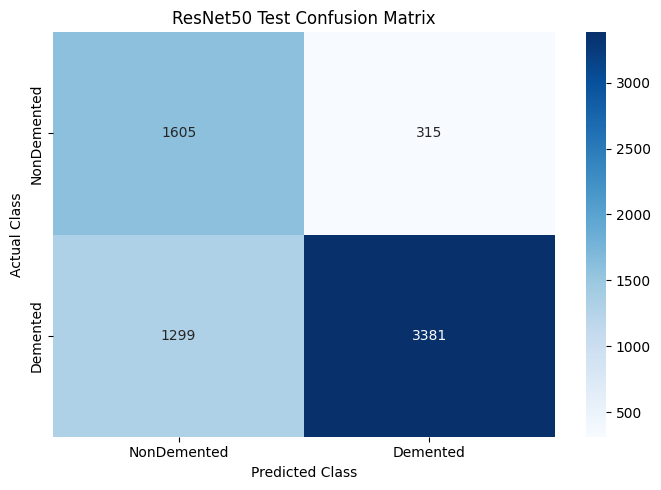

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("ResNet50 Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Test Loss:", round(test_loss, 4))

print("Accuracy:", round(
    accuracy_score(true_labels, test_predictions), 4
))

print("Precision:", round(
    precision_score(true_labels, test_predictions), 4
))

print("Recall:", round(
    recall_score(true_labels, test_predictions), 4
))

print("F1-score:", round(
    f1_score(true_labels, test_predictions), 4
))

print("ROC-AUC:", round(
    roc_auc_score(true_labels, test_probabilities), 4
))

Test Loss: 0.506
Accuracy: 0.7555
Precision: 0.9148
Recall: 0.7224
F1-score: 0.8073
ROC-AUC: 0.8651


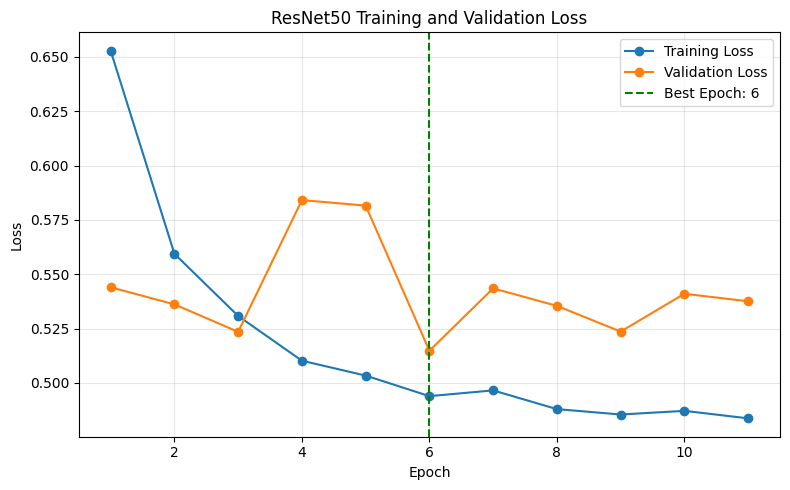

In [27]:
history_df = pd.DataFrame(history.history)
history_df.index = range(1, len(history_df) + 1)

best_epoch = history_df["val_loss"].idxmin()

plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.title("ResNet50 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

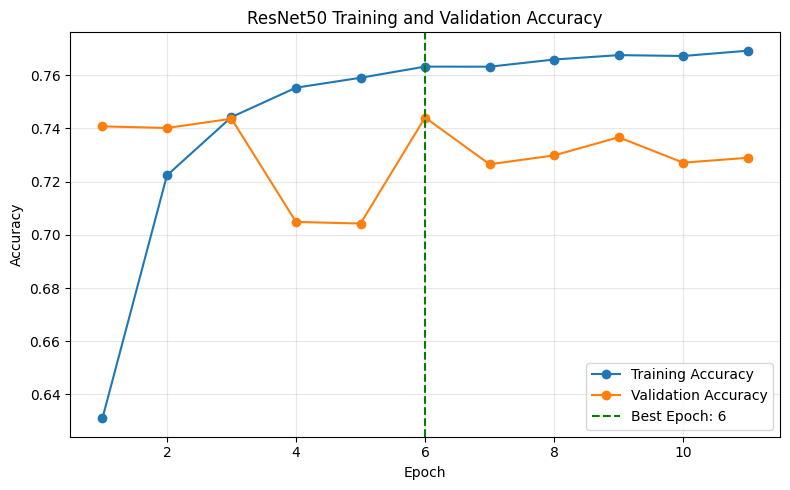

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df.index,
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.title("ResNet50 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

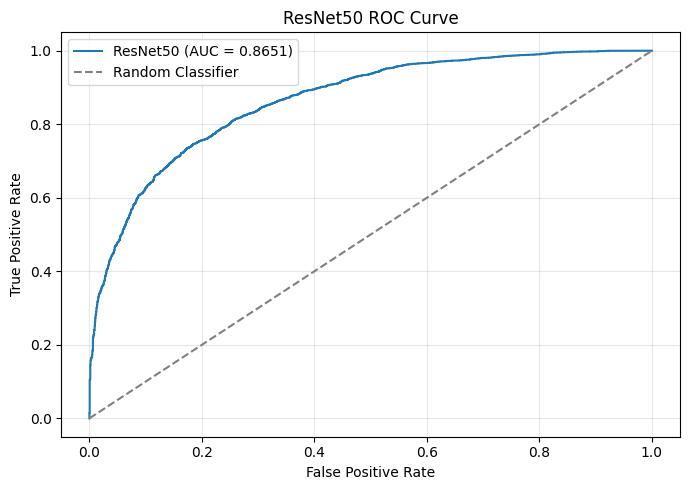

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(
    true_labels,
    test_probabilities
)

roc_auc = roc_auc_score(
    true_labels,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet50 (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("ResNet50 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

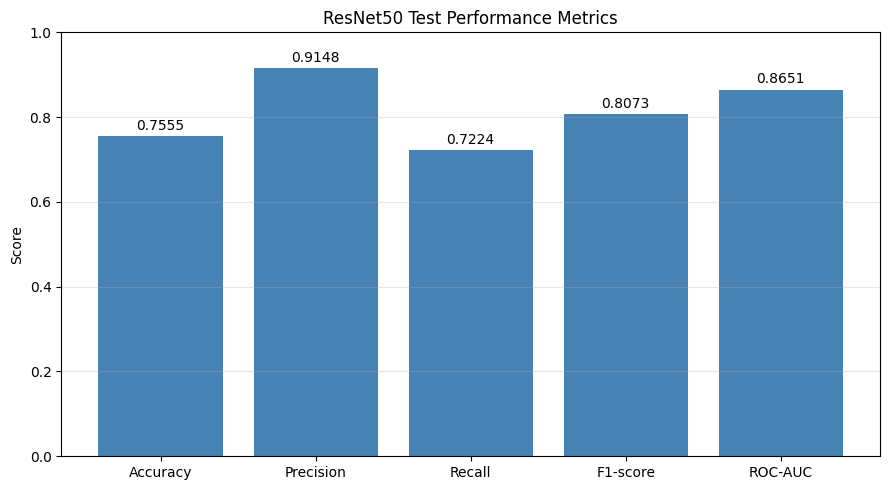

In [30]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

metric_values = [
    accuracy_score(true_labels, test_predictions),
    precision_score(true_labels, test_predictions),
    recall_score(true_labels, test_predictions),
    f1_score(true_labels, test_predictions),
    roc_auc_score(true_labels, test_probabilities)
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metric_names,
    metric_values,
    color="steelblue"
)

plt.ylim(0, 1)
plt.title("ResNet50 Test Performance Metrics")
plt.ylabel("Score")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()